In [107]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import plotly.express as px 
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

In [79]:
df = pd.read_csv("Credit Card Customer Data.csv")

In [80]:
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Sl_No                660 non-null    int64
 1   Customer Key         660 non-null    int64
 2   Avg_Credit_Limit     660 non-null    int64
 3   Total_Credit_Cards   660 non-null    int64
 4   Total_visits_bank    660 non-null    int64
 5   Total_visits_online  660 non-null    int64
 6   Total_calls_made     660 non-null    int64
dtypes: int64(7)
memory usage: 36.2 KB


In [82]:
df['Sl_No']

0        1
1        2
2        3
3        4
4        5
      ... 
655    656
656    657
657    658
658    659
659    660
Name: Sl_No, Length: 660, dtype: int64

In [83]:
df['Customer Key']

0      87073
1      38414
2      17341
3      40496
4      47437
       ...  
655    51108
656    60732
657    53834
658    80655
659    80150
Name: Customer Key, Length: 660, dtype: int64

In [84]:
df.drop(['Sl_No','Customer Key'],axis=1,inplace=True)

In [85]:
df.describe()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
count,660.000000,660.000000,660.000000,660.000000,660.000000
mean,34574.242424,4.706061,2.403030,2.606061,3.583333
std,37625.487804,2.167835,1.631813,2.935724,2.865317
min,3000.000000,1.000000,0.000000,0.000000,0.000000
25%,10000.000000,3.000000,1.000000,1.000000,1.000000
50%,18000.000000,5.000000,2.000000,2.000000,3.000000
75%,48000.000000,6.000000,4.000000,4.000000,5.000000
max,200000.000000,10.000000,5.000000,15.000000,10.000000


In [86]:
df.isnull().sum()

Avg_Credit_Limit       0
Total_Credit_Cards     0
Total_visits_bank      0
Total_visits_online    0
Total_calls_made       0
dtype: int64

## There are no missing values 
## A Customer carries ~5 CreditCards on an average 
## There are customers who don't visit banks / online/ calls  

In [87]:
fig = px.scatter_matrix(df, dimensions=['Avg_Credit_Limit','Total_Credit_Cards','Total_visits_bank','Total_visits_online','Total_calls_made'],color='Avg_Credit_Limit',title='Pairplot of Credit Card Customer Data')

fig.update_layout(width=1200,height=1000)
fig.show()

In [88]:
px.scatter(df,x='Avg_Credit_Limit',y='Total_visits_online')

In [89]:
px.scatter(df,x='Avg_Credit_Limit',y='Total_Credit_Cards')

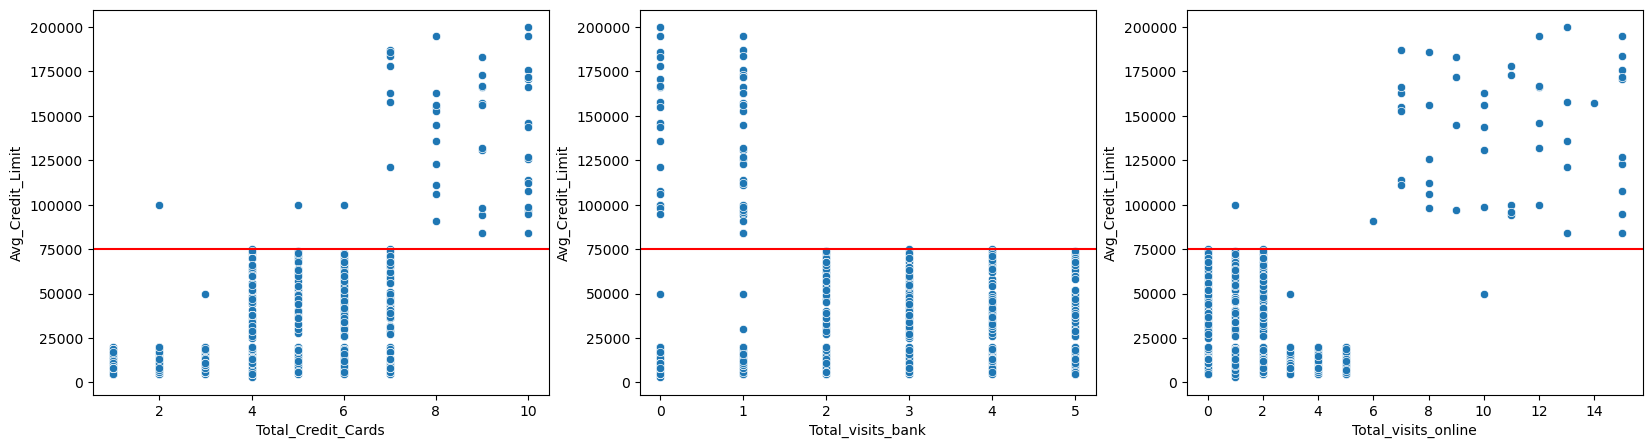

In [93]:
fig , ax = plt.subplots(1,3,figsize=(20,5))
sns.scatterplot(x='Total_Credit_Cards',y='Avg_Credit_Limit',data=df,ax=ax[0])
ax[0].axhline(y=75000,color='r',linestyle='-')
sns.scatterplot(x='Total_visits_bank',y='Avg_Credit_Limit',data=df,ax=ax[1])
ax[1].axhline(y=75000,color='r',linestyle='-')
sns.scatterplot(x='Total_visits_online',y='Avg_Credit_Limit',data=df,ax=ax[2])
ax[2].axhline(y=75000,color='r',linestyle='-')

We May get 2 Segments [Above 75000 and lower than 75000]

** High Avg_Credit_Limit & High Total_Visits_Online & High Credit Cards & Low Total visits bank


** Low Avg_Credit_Limit & Low Total_Visits_Online & Low Credit Cards & Hight Total visits bank

In [94]:
X = df.drop(['Total_calls_made'],axis=1)

In [95]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [96]:
kmenas = KMeans(random_state=111)
kmenas.fit(X_scaled)

c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\be485\AppData\Local\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\be485\AppData\Local\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,


KMeans(random_state=111)

In [97]:
pd.Series(kmenas.labels_).value_counts()

5    160
2    102
0     95
6     88
1     87
4     78
7     27
3     23
Name: count, dtype: int64

c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.

c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.

c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.

c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory le

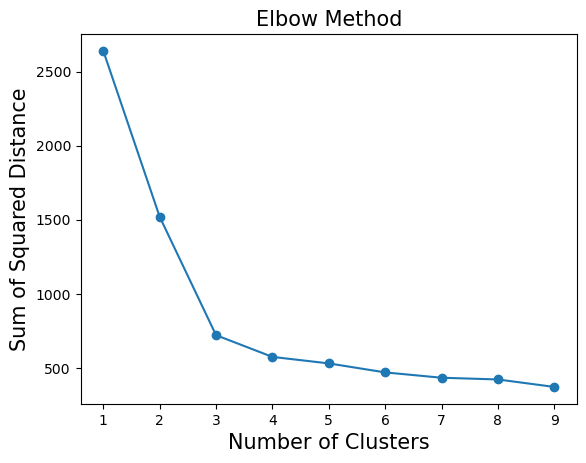

In [98]:
a = []
K = range(1,10)
for i in K:
    kmenas = KMeans(n_clusters=i)
    kmenas.fit(X_scaled)
    a.append(kmenas.inertia_)

plt.plot(K,a,marker='o')
plt.title('Elbow Method',fontsize=15)
plt.xlabel('Number of Clusters',fontsize=15)
plt.ylabel('Sum of Squared Distance',fontsize=15)
plt.show()

In [99]:
a = []
K = range(1,10)
for i in K:
    kmean= KMeans(n_clusters=i,random_state=111)
    kmean.fit(X_scaled)
    a.append(kmean.inertia_)

px.line(x=K,y=a,title='Elbow Method')

c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.

c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.

c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.

c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory le

In [100]:
kmeans3 = KMeans(n_clusters=3 , random_state=111)
kmeans3.fit(X_scaled)

pd.Series(kmeans3.labels_).value_counts()

c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.



2    379
1    231
0     50
Name: count, dtype: int64

In [101]:
cluster_label_3 = kmeans3.fit_predict(X_scaled)

c:\Users\be485\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.



In [103]:
df['Kmeans_3Clusters'] = cluster_label_3 

In [104]:
df.head()

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Kmeans_3Clusters
0,100000,2,1,1,0,1
1,50000,3,0,10,9,1
2,50000,7,1,3,4,2
3,30000,5,1,1,4,1
4,100000,6,0,12,3,0


In [105]:
df.groupby('Kmeans_3Clusters')['Avg_Credit_Limit'].agg(['min','max','mean'])

,min,max,mean
Kmeans_3Clusters,,,
0,84000,200000,141040.000000
1,3000,100000,12722.943723
2,5000,75000,33846.965699


In [106]:
fig = px.box(df,x='Kmeans_3Clusters',y='Avg_Credit_Limit',color='Kmeans_3Clusters')

fig.add_shape(type="line",x0=-0.5, y0=78000 , x1=2.5 , y1=78000 , line=dict(color="Red",width=2))
fig.add_shape(type="line",x0=-0.5, y0=12500 , x1=2.5 , y1=12500 , line=dict(color="Red",width=2))
fig.show()

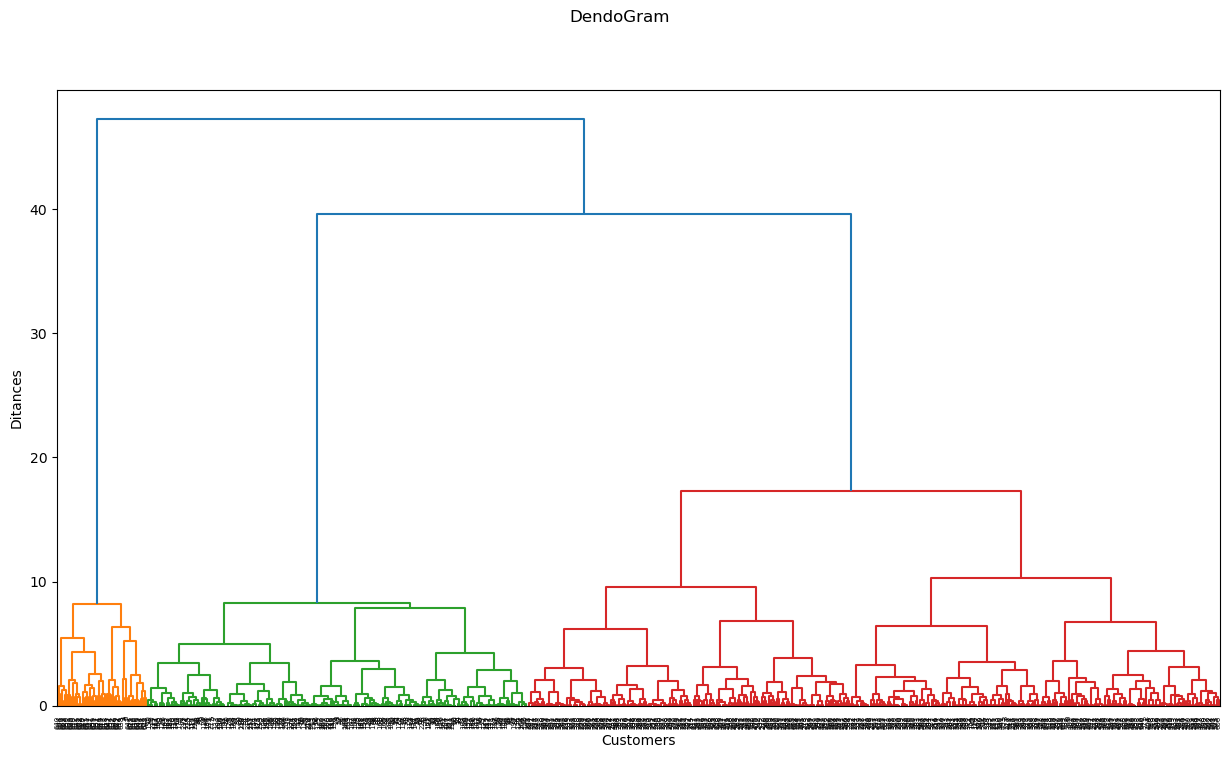

In [108]:
fig = plt.figure(figsize=(15,8))
dendogram = sch.dendrogram(sch.linkage(X_scaled,method='ward'))
plt.suptitle('DendoGram')
plt.xlabel('Customers')
plt.ylabel('Ditances')
plt.show()

In [110]:
hc3 = AgglomerativeClustering(n_clusters=3, metric='euclidean',linkage='ward')

y_hc3 = hc3.fit_predict(X_scaled)

In [111]:
df['Agg_3Clusters'] = y_hc3
df

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made,Kmeans_3Clusters,Agg_3Clusters
0,100000,2,1,1,0,1,0
1,50000,3,0,10,9,1,1
2,50000,7,1,3,4,2,0
3,30000,5,1,1,4,1,0
4,100000,6,0,12,3,0,1
...,...,...,...,...,...,...,...
655,99000,10,1,10,0,0,1
656,84000,10,1,13,2,0,1
657,145000,8,1,9,1,0,1
658,172000,10,1,15,0,0,1


In [112]:
from sklearn.metrics import silhouette_score
sil_kmeans = silhouette_score(X_scaled,df['Kmeans_3Clusters'])
sil_agg = silhouette_score(X_scaled,df['Agg_3Clusters'])

print("Kmeans ", sil_kmeans)
print("Agglomrative" , sil_agg)

Kmeans  0.49069829816445293
Agglomrative 0.48595151547112686


In [114]:
import pickle 

pickle.dump(scaler, open('scaler.pkl','wb'))

pickle.dump(kmeans3,open('model.pkl','wb'))

In [127]:
%%writefile app.py
import streamlit as st
import pandas as pd 
import pickle

st.title('Customer Segmentation')

st.write(
    '''
This App segments the customers into 3 Clusters based on thier credit card usage.
''')

st.write(''' ## Clusters:
* **Cluster "A"**: (High Value Customers) , High Credit Limit (>80000) , High Spending Power , Low Bank Visits , Active Online Usage
* **Cluster "B"**: (Low Value Customers) , Low Credit Limit , Few Credit Cards , Low Ativity , May be new or Inactive Customers 
* **Cluster "C"**: (Medium Value Customers) , Medium Credit Limit , Medium Number of Credit Cards , Balance Visit , Potential to Grow to High Value
''')
st.image('https://helprace.com/wp-content/uploads/2019/02/customer-segmentation.png',width=700)

avg_credit_limit = st.slider('Average Credit Limit', 1000 , 200000 , 10000)
total_credit_cards = st.slider('Total Credit Cards' , 1 , 10 , 1)
total_visits_bank = st.slider('Total Visits Bank' , 0, 5 , 1)
total_visit_online = st.slider('Total Visits Online' , 0 , 5 , 1)

X = pd.DataFrame({
    'Avg_Credit_Limit' : [avg_credit_limit],
    'Total_Credit_Cards' : [total_credit_cards],
    'Total_visits_bank' : [total_visits_bank],
    'Total_visits_online' : [total_visit_online]
})

scaler = pickle.load(open('scaler.pkl','rb'))
X_scaled = scaler.transform(X)

model = pickle.load(open('model.pkl','rb'))
prediction = model.predict(X_scaled)

st.write('''
# Result
''')

if prediction == 0:
    st.write('Customer Belongs to Cluster "A" Which is VIP')
elif prediction == 1:
    st.write('Customer Belongs to Cluster "C" Which is LOW Value Customer')
else:
    st.write('Customer Belongs to Cluster "B" Which is Medium Value')

Overwriting app.py


In [128]:
!streamlit run app.py

^C
